In [14]:
import numpy as np
import matplotlib.pyplot as plt
import time

from skimage.io import imread, imsave
from skimage import color, filters, exposure, morphology, measure, feature
from skimage.filters import rank

from scipy import ndimage as ndi
from skimage.filters import threshold_otsu
from sklearn.cluster import KMeans


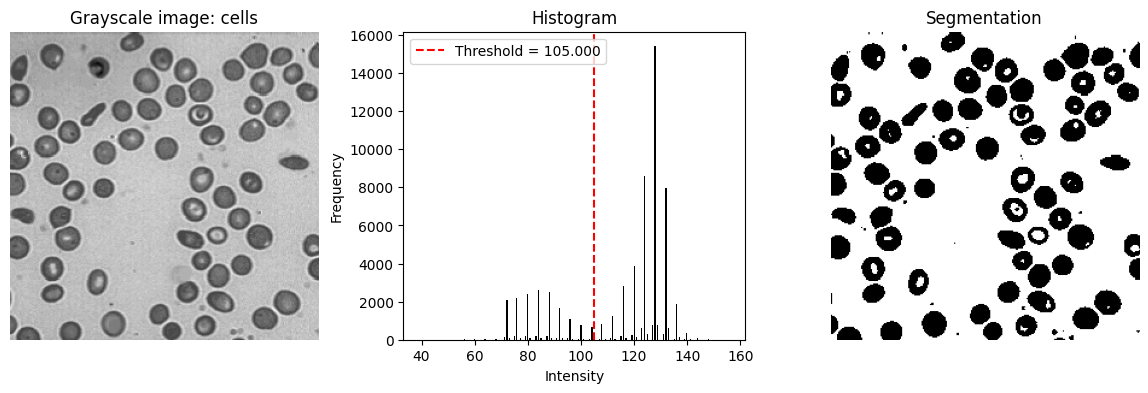

In [10]:

cells = imread("../Images/cells.bmp", as_gray=True)
threshold = threshold_otsu(cells)
segmented_cells = cells > threshold

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(cells, cmap="gray")
axes[0].set_title("Grayscale image: cells")
axes[0].axis("off")

axes[1].hist(cells.ravel(), bins=256, color="black")
axes[1].axvline(threshold, color="red", linestyle="--", label=f"Threshold = {threshold:.3f}")
axes[1].set_title("Histogram")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Frequency")
axes[1].legend()

axes[2].imshow(segmented_cells, cmap="gray")
axes[2].set_title("Segmentation")
axes[2].axis("off")


plt.show()

Manual threshold (pseudo algo): 105.318
Otsu threshold: 105.000
Difference: 0.318


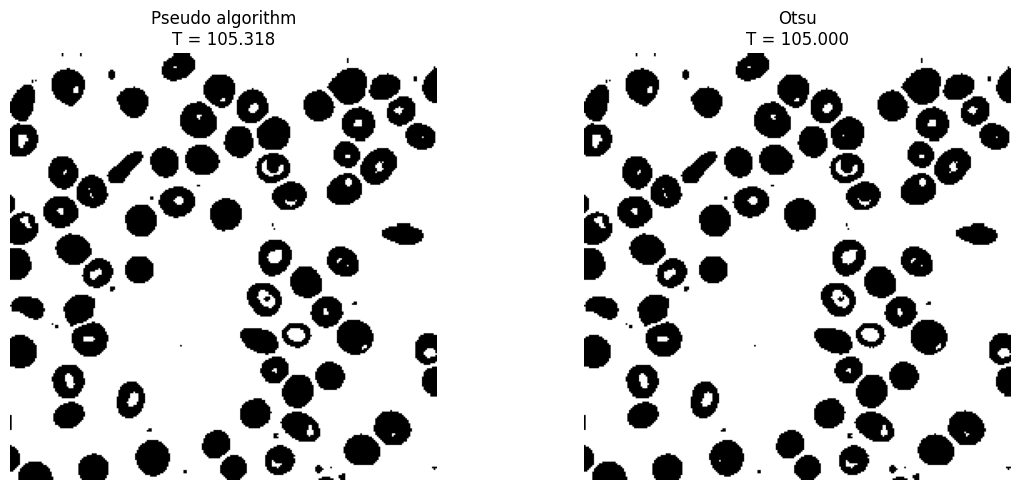

In [12]:
def auto_thresh(image, epsilon=0.5):
    image = np.asarray(image, dtype=float)
    s = 0.5 * (np.amin(image) + np.amax(image))
    done = False

    while not done:
        B = image >= s
        s_next = 0.5 * (np.mean(image[B]) + np.mean(image[~B]))
        done = abs(s - s_next) < epsilon
        s = s_next

    return s


cells = imread("../Images/cells.bmp", as_gray=True)
manual_threshold = auto_thresh(cells)
automatic_threshold = threshold_otsu(cells)

manual_segmented = cells >= manual_threshold
automatic_segmented = cells >= automatic_threshold

print(f"Manual threshold (pseudo algo): {manual_threshold:.3f}")
print(f"Otsu threshold: {automatic_threshold:.3f}")
print(f"Difference: {abs(manual_threshold - automatic_threshold):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(manual_segmented, cmap="gray")
axes[0].set_title(f"Pseudo algorithm\nT = {manual_threshold:.3f}")
axes[0].axis("off")

axes[1].imshow(automatic_segmented, cmap="gray")
axes[1].set_title(f"Otsu\nT = {automatic_threshold:.3f}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Computation time: 0.0286 s
Cluster centers:
[[ 2.85692167e+00  3.88704937e+00]
 [-5.11235752e+00 -3.10313767e+00]
 [-9.57681805e-04  1.42778668e-01]]


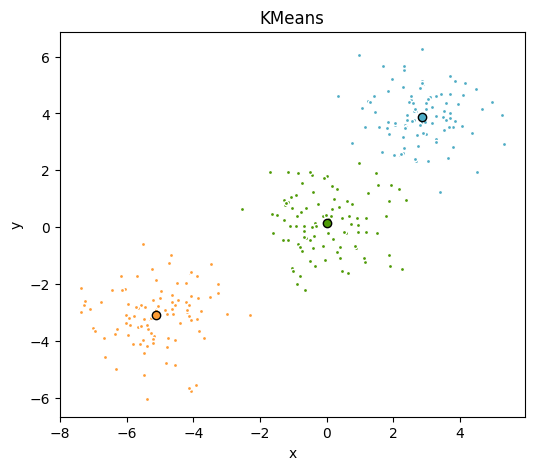

In [19]:
def generation(n, x, y):
    Y = np.random.randn(n, 2) + np.dot(np.ones((n, 2)), np.array(((x, 0), (0, y))))
    return Y


np.random.seed(0)
points1 = generation(100, 0, 0)
points2 = generation(100, 3, 4)
points3 = generation(100, -5, -3)
pts = np.concatenate((points1, points2, points3))

n = 3
kmeans = KMeans(init="k-means++", n_clusters=n, n_init=10, random_state=0)
t0 = time.time()
kmeans.fit(pts)
t_batch = time.time() - t0

kmeans_labels = kmeans.labels_
kmeans_cluster_centers = kmeans.cluster_centers_

print(f"Computation time: {t_batch:.4f} s")
print("Cluster centers:")
print(kmeans_cluster_centers)

fig = plt.figure(figsize=(6, 5))
colors = ["#4EACC5", "#FF9C34", "#4E9A06"]

for k, col in zip(range(n), colors):
    my_members = kmeans_labels == k
    cluster_center = kmeans_cluster_centers[k]

    plt.plot(pts[my_members, 0], pts[my_members, 1], "w", markerfacecolor=col, marker=".")
    plt.plot(cluster_center[0], cluster_center[1], "o", markerfacecolor=col, markeredgecolor="k", markersize=6)

plt.title("KMeans")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

fig.savefig("kmeans.pdf")

For the 3-D K-means segmentation, the points that must be separated are the image pixels.
Each pixel is represented by its RGB coordinates $(R, G, B)$, so the image is transformed into a matrix of size $N \times 3$, where $N$ is the number of pixels.
The 3 classes correspond to 3 groups of pixels with similar color intensities.

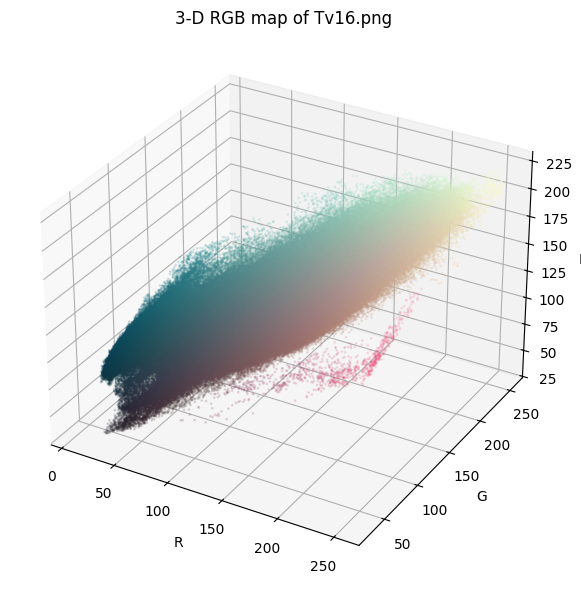

Computation time: 2.0179 s
Cluster centers (RGB):
[[ 51.13036   93.37525   98.945404]
 [139.1261   131.63641  123.908554]
 [180.72092  192.80708  163.3234  ]]


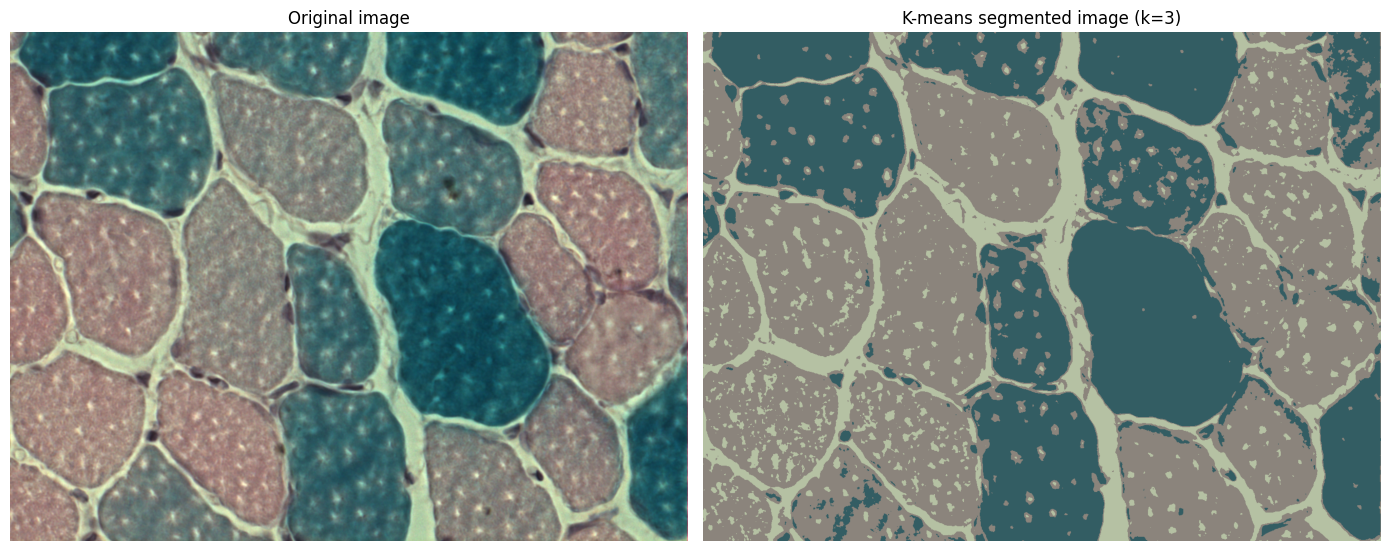

In [21]:
image = imread("../Images/Tv16.png")
display_image = image.copy()

if image.dtype != np.float32 and image.dtype != np.float64:
    image = image.astype(np.float32)

nLines, nCols, nChannels = image.shape
data = np.reshape(image, (nLines * nCols, nChannels)).astype(np.float32)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=data / 255.0, s=1, alpha=0.15)
ax.set_xlabel("R")
ax.set_ylabel("G")
ax.set_zlabel("B")
ax.set_title("3-D RGB map of Tv16.png")
plt.tight_layout()
plt.show()

k = 3
kmeans_color = KMeans(init="k-means++", n_clusters=k, n_init=10, random_state=0)
t0 = time.time()
kmeans_color.fit(data)
t_batch = time.time() - t0

k_means_labels = kmeans_color.labels_
k_means_cluster_centers = kmeans_color.cluster_centers_
result = np.reshape(k_means_labels, (nLines, nCols))
segmented_image = np.clip(np.rint(k_means_cluster_centers[result]), 0, 255).astype(np.uint8)

print(f"Computation time: {t_batch:.4f} s")
print("Cluster centers (RGB):")
print(k_means_cluster_centers)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(display_image)
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(segmented_image)
axes[1].set_title("K-means segmented image (k=3)")
axes[1].axis("off")

plt.tight_layout()
plt.show()